# Census Income: Normalizacion, Regularizacion y Optimizacion

Notebook educativo que demuestra **paso a paso** las tecnicas fundamentales para entrenar redes neuronales:

1. **Normalizacion** de caracteristicas (media=0, std=1)
2. **Dropout** para reducir overfitting
3. **Early Stopping** para evitar sobreentrenamiento
4. **Comparacion** de tecnicas y su impacto
5. **Evaluacion** con multiples metricas

**Objetivo:** Predecir `occupation` (14 clases) usando todas las variables del dataset.

## 1. Importes y Configuracion

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("Importes completados.")

Importes completados.


In [2]:
# Configuracion de reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Reproducibilidad configurada con seed={SEED}')

Device: cpu
Reproducibilidad configurada con seed=42


## 2. Carga de Datos

Cargar el dataset y realizar limpieza basica:
- Eliminar espacios en blanco
- Reemplazar '?' por NaN
- Eliminar filas con target faltante

In [3]:
# Cargar dataset
df = pd.read_csv('adult.csv').copy()
df.columns = [c.strip() for c in df.columns]
print(f"Datos originales: {df.shape}")

Datos originales: (32561, 15)


In [4]:
# Limpiar espacios en blanco
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Reemplazar '?' por NaN
df = df.replace('?', np.nan)
print(f"Datos limpios de espacios y valores faltantes")

Datos limpios de espacios y valores faltantes


C:\Users\jorge\AppData\Local\Temp\ipykernel_16492\4018196427.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [5]:
# Definir target
target_col = 'occupation'
df_clean = df.dropna(subset=[target_col]).copy()

print(f"Dataset final: {df_clean.shape}")
print(f"Clases: {df_clean[target_col].nunique()}")
print(f"Clases: {sorted(df_clean[target_col].unique().tolist())}")

Dataset final: (30718, 15)
Clases: 14
Clases: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']


## 3. Separacion de Features y Target

Separar caracteristicas (X) del target (y) y codificar las clases numericamente.

In [6]:
# Separar X y y
X = df_clean.drop(target_col, axis=1)
y = df_clean[target_col]
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (30718, 14)
y shape: (30718,)


In [7]:
# Encodificar target (convertir strings a numeros)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Target encoding completado")
print(f"Clases (encoded): {np.unique(y_encoded)}")
print(f"Total de clases: {len(np.unique(y_encoded))}")

Target encoding completado
Clases (encoded): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Total de clases: 14


## 4. Preprocesamiento con ColumnTransformer

Pipeline que:
- **Numéricas:** Imputa con media, luego estandariza
- **Categóricas:** Imputa con 'missing', luego OneHotEncoding

In [8]:
# Identificar tipos de features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Features numericas ({len(numeric_features)}): {numeric_features}")
print(f"Features categoricas ({len(categorical_features)}): {categorical_features}")

Features numericas (6): ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Features categoricas (8): ['workclass', 'education', 'marital.status', 'relationship', 'race', 'sex', 'native.country', 'income']


C:\Users\jorge\AppData\Local\Temp\ipykernel_16492\3371973560.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [9]:
# Pipeline para features numericas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

print("Pipeline numerico: Imputer -> StandardScaler")

Pipeline numerico: Imputer -> StandardScaler


In [10]:
# Pipeline para features categoricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print("Pipeline categorico: Imputer -> OneHotEncoder")

Pipeline categorico: Imputer -> OneHotEncoder


In [11]:
# Combinar pipelines con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("ColumnTransformer creado")

ColumnTransformer creado


In [12]:
# Aplicar transformaciones
X_transformed = preprocessor.fit_transform(X)

print(f"X despues de preprocesamiento: {X_transformed.shape}")
print(f"Todas las features son ahora numericas")

X despues de preprocesamiento: (30718, 93)
Todas las features son ahora numericas


## 5. Division en Train, Validation y Test

Estrategia:
- **Train:** 68% - Para entrenar
- **Validation:** 17% - Para monitorear durante entrenamiento
- **Test:** 15% - Para evaluacion final

In [13]:
# Primera division: Train+Val (85%) vs Test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_transformed, y_encoded, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Despues primera division:")
print(f"  X_temp: {X_temp.shape} (sera train+val)")
print(f"  X_test: {X_test.shape} (evaluacion final)")

Despues primera division:
  X_temp: (26110, 93) (sera train+val)
  X_test: (4608, 93) (evaluacion final)


In [14]:
# Segunda division: Train (80%) vs Val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_temp
)

print(f"Despues segunda division:")
print(f"  X_train: {X_train.shape} (68% del total)")
print(f"  X_val:   {X_val.shape} (17% del total)")
print(f"  X_test:  {X_test.shape} (15% del total)")

Despues segunda division:
  X_train: (20888, 93) (68% del total)
  X_val:   (5222, 93) (17% del total)
  X_test:  (4608, 93) (15% del total)


## 6. Normalizacion de Caracteristicas

**Normalizacion:** Transformar features para que tengan media=0 y desviacion standar=1

Formula: `x_norm = (x - mean) / std`

**Importante:** Calcular media y std SOLO del training set, aplicar a todos.

In [15]:
# Calcular estadisticas SOLO del training set
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std = np.where(std == 0, 1, std)  # Evitar division por cero

print(f"Media calculada (primeras 5): {mean[:5]}")
print(f"Std calculada (primeras 5): {std[:5]}")

Media calculada (primeras 5): [ 0.01034793 -0.00240038 -0.00345656  0.00270443  0.00321346]
Std calculada (primeras 5): [1.00219843 1.00163173 1.00395714 1.01030905 1.01113836]


In [16]:
# Normalizar todos los conjuntos usando media y std del training
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_norm = (X_test - mean) / std

print(f"Normalizacion completada")

Normalizacion completada


In [17]:
# Verificar normalizacion
print(f"Verificacion:")
print(f"  X_train_norm mean (debe ser ~0): {X_train_norm.mean(axis=0)[:5]}")
print(f"  X_train_norm std (debe ser ~1): {X_train_norm.std(axis=0)[:5]}")

Verificacion:
  X_train_norm mean (debe ser ~0): [ 3.24488298e-18  5.43440663e-17 -1.17129380e-15 -1.04594192e-15
 -2.40199473e-15]
  X_train_norm std (debe ser ~1): [1. 1. 1. 1. 1.]


## 7. Creacion de DataLoaders

Convertir arrays numpy a tensores PyTorch y crear DataLoaders para entrenamiento.

In [18]:
# Convertir a tensores PyTorch
train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_train_norm),
    torch.LongTensor(y_train)
)

val_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_val_norm),
    torch.LongTensor(y_val)
)

test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test_norm),
    torch.LongTensor(y_test)
)

print(f"Datasets creados")

Datasets creados


In [19]:
# Crear DataLoaders
batch_size = 32

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=len(val_dataset), shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=len(test_dataset), shuffle=False
)

print(f"DataLoaders creados")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

DataLoaders creados
  Train batches: 653
  Val batches: 1
  Test batches: 1


In [20]:
# Variables globales para el modelo
num_classes = y_encoded.max() + 1
input_size = X_train_norm.shape[1]

print(f"Parametros del modelo:")
print(f"  Input size: {input_size}")
print(f"  Num classes: {num_classes}")

Parametros del modelo:
  Input size: 93
  Num classes: 14


## 8. Definicion de Modelos

Dos arquitecturas:
- **BaselineModel:** 2 capas hidden, sin regularizacion
- **RegularizedModel:** 2 capas hidden, CON Dropout entre capas

In [21]:
# Modelo baseline (sin regularizacion)
class BaselineModel(nn.Module):
    def __init__(self, input_size, num_classes, hidden=256):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, num_classes)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

print("BaselineModel definido")

BaselineModel definido


In [22]:
# Modelo con Dropout (regularizacion)
class RegularizedModel(nn.Module):
    def __init__(self, input_size, num_classes, hidden=256, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden, hidden)
        self.drop2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden, num_classes)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.drop1(x)
        x = torch.relu(self.fc2(x))
        x = self.drop2(x)
        return self.fc3(x)

print("RegularizedModel definido")

RegularizedModel definido


## 9. Funcion de Entrenamiento

Funcion `fit()` que:
- Entrena el modelo en datos normalizados
- Monitorea validacion
- Soporta Early Stopping
- Guarda mejores pesos

In [23]:
def fit(model, train_loader, val_loader, optimizer, epochs, early_stopping_patience=0, model_name="model"):
    """Entrena modelo con validacion y early stopping."""
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    patience_counter = 0
    
    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        train_loss = train_acc = train_count = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
            train_acc += (y_pred.argmax(dim=1) == y_batch).sum().item()
            train_count += len(y_batch)
        
        train_loss, train_acc = train_loss / train_count, train_acc / train_count
        
        # Validation
        model.eval()
        val_loss = val_acc = val_count = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_acc += (y_pred.argmax(dim=1) == y_batch).sum().item()
                val_count += len(y_batch)
        
        val_loss, val_acc = val_loss / val_count, val_acc / val_count
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Early Stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            if epoch % 10 == 1 or epoch == 1:
                print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Val: {val_acc:.4f} *")
        else:
            patience_counter += 1
            if epoch % 20 == 0:
                print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Val: {val_acc:.4f}")
        
        if early_stopping_patience > 0 and patience_counter >= early_stopping_patience:
            print(f"Early Stop en epoch {epoch}.")
            model.load_state_dict(torch.load(f'{model_name}_best.pth'))
            break
    
    if early_stopping_patience == 0:
        model.load_state_dict(torch.load(f'{model_name}_best.pth'))
    
    return history

print("Funcion fit() definida")

Funcion fit() definida


## 10. Experimento 1: Baseline (Sin Regularizacion)

In [24]:
print("="*70)
print("EXPERIMENTO 1: BASELINE (Sin Regularizacion)")
print("="*70)

models = {}
histories = {}

models['baseline'] = BaselineModel(input_size, num_classes).to(device)
opt = torch.optim.Adam(models['baseline'].parameters(), lr=0.001)
histories['baseline'] = fit(models['baseline'], train_loader, val_loader, opt, 
                            epochs=50, model_name="baseline")

print(f"\nMejor Val Acc: {max(histories['baseline']['val_acc']):.4f}\n")

EXPERIMENTO 1: BASELINE (Sin Regularizacion)
Epoch   1 | Loss: 1.9553 | Acc: 0.3203 | Val: 0.3397 *
Epoch  20 | Loss: 1.4586 | Acc: 0.4706 | Val: 0.3183
Epoch  40 | Loss: 1.1624 | Acc: 0.5696 | Val: 0.3020

Mejor Val Acc: 0.3512



## 11. Experimento 2: Con Dropout (p=0.3)

In [25]:
print("="*70)
print("EXPERIMENTO 2: CON DROPOUT (p=0.3)")
print("="*70)

models['dropout'] = RegularizedModel(input_size, num_classes, dropout=0.3).to(device)
opt = torch.optim.Adam(models['dropout'].parameters(), lr=0.001)
histories['dropout'] = fit(models['dropout'], train_loader, val_loader, opt, 
                          epochs=50, model_name="dropout")

print(f"\nMejor Val Acc: {max(histories['dropout']['val_acc']):.4f}\n")

EXPERIMENTO 2: CON DROPOUT (p=0.3)
Epoch   1 | Loss: 1.9969 | Acc: 0.3072 | Val: 0.3393 *
Epoch  20 | Loss: 1.7559 | Acc: 0.3708 | Val: 0.3407
Epoch  40 | Loss: 1.6845 | Acc: 0.3930 | Val: 0.3422

Mejor Val Acc: 0.3520



## 12. Experimento 3: Con Early Stopping (patience=10)

In [26]:
print("="*70)
print("EXPERIMENTO 3: CON EARLY STOPPING (patience=10)")
print("="*70)

models['early_stopping'] = BaselineModel(input_size, num_classes).to(device)
opt = torch.optim.Adam(models['early_stopping'].parameters(), lr=0.001)
histories['early_stopping'] = fit(models['early_stopping'], train_loader, val_loader, opt, 
                                  epochs=100, early_stopping_patience=10, model_name="early_stopping")

print(f"\nMejor Val Acc: {max(histories['early_stopping']['val_acc']):.4f}")
print(f"Epocas ejecutadas: {len(histories['early_stopping']['train_loss'])}\n")

EXPERIMENTO 3: CON EARLY STOPPING (patience=10)
Epoch   1 | Loss: 1.9531 | Acc: 0.3182 | Val: 0.3340 *
Early Stop en epoch 16.

Mejor Val Acc: 0.3480
Epocas ejecutadas: 16



## 13. Experimento 4: Dropout + Early Stopping (Combinado)

In [27]:
print("="*70)
print("EXPERIMENTO 4: DROPOUT + EARLY STOPPING (Combinado)")
print("="*70)

models['combined'] = RegularizedModel(input_size, num_classes, dropout=0.3).to(device)
opt = torch.optim.Adam(models['combined'].parameters(), lr=0.001)
histories['combined'] = fit(models['combined'], train_loader, val_loader, opt, 
                           epochs=100, early_stopping_patience=10, model_name="combined")

print(f"\nMejor Val Acc: {max(histories['combined']['val_acc']):.4f}")
print(f"Epocas ejecutadas: {len(histories['combined']['train_loss'])}\n")

EXPERIMENTO 4: DROPOUT + EARLY STOPPING (Combinado)
Epoch   1 | Loss: 1.9935 | Acc: 0.3107 | Val: 0.3361 *
Epoch  20 | Loss: 1.7535 | Acc: 0.3747 | Val: 0.3435
Early Stop en epoch 22.

Mejor Val Acc: 0.3547
Epocas ejecutadas: 22



## 14. Comparacion de Resultados

In [28]:
# Tabla de comparacion
results_table = pd.DataFrame({
    'Modelo': ['Baseline', 'Dropout', 'Early Stopping', 'Dropout + ES'],
    'Best Val Acc': [max(histories[name]['val_acc']) for name in ['baseline', 'dropout', 'early_stopping', 'combined']],
    'Epocas': [len(histories[name]['train_loss']) for name in ['baseline', 'dropout', 'early_stopping', 'combined']]
})

print("\n" + "="*70)
print("COMPARACION INICIAL DE MODELOS")
print("="*70)
print(results_table.to_string(index=False))
print("="*70)


COMPARACION INICIAL DE MODELOS
        Modelo  Best Val Acc  Epocas
      Baseline      0.351206      50
       Dropout      0.351972      50
Early Stopping      0.347951      16
  Dropout + ES      0.354653      22


## 15. Visualizacion de Entrenamientos

Graficos comparativos de Loss y Accuracy para cada experimento.

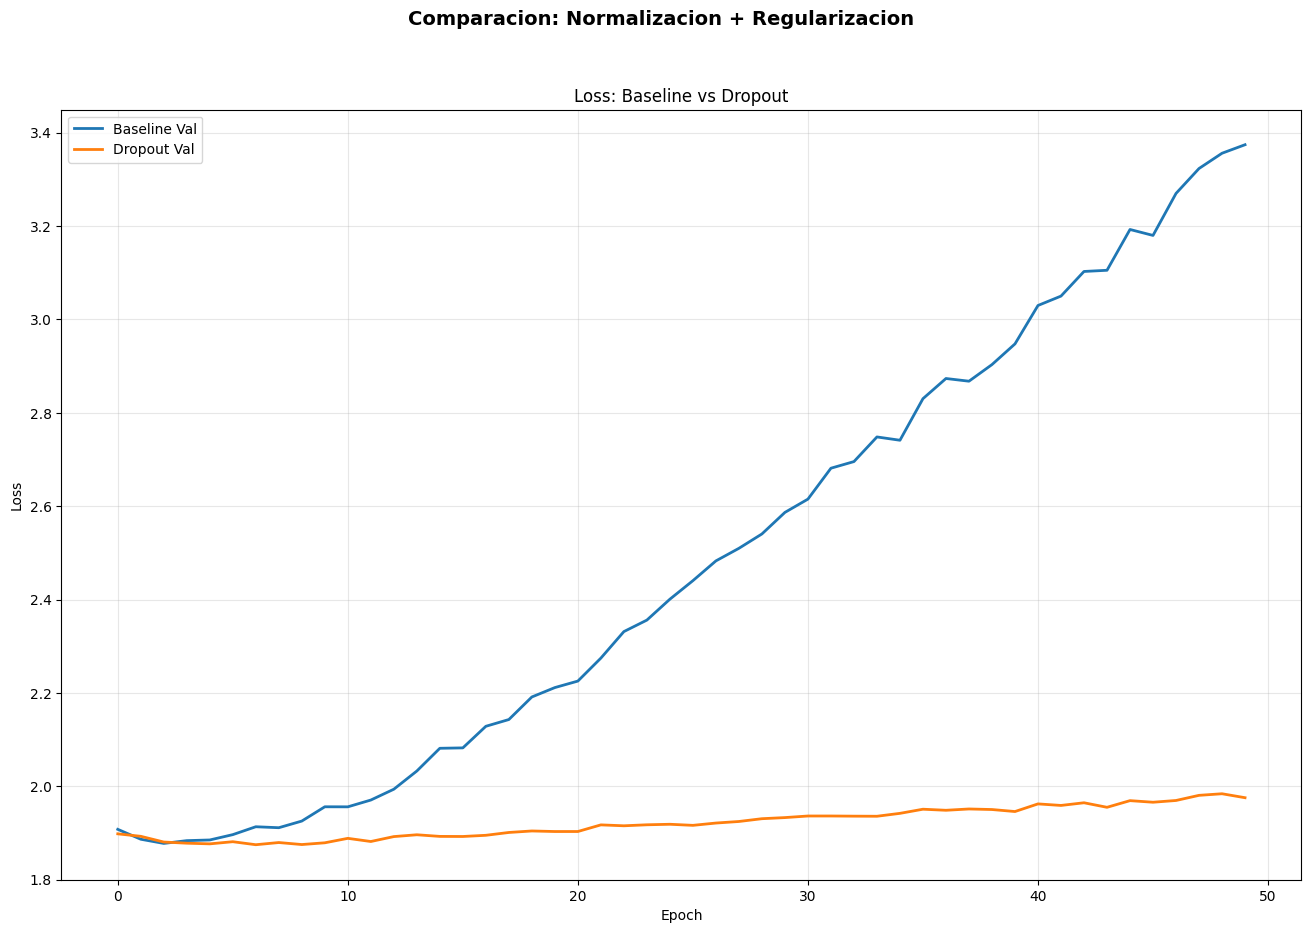

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
fig.suptitle('Comparacion: Normalizacion + Regularizacion', fontsize=14, fontweight='bold')

# Graficar
ax.plot(histories['baseline']['val_loss'], label='Baseline Val', linewidth=2)
ax.plot(histories['dropout']['val_loss'], label='Dropout Val', linewidth=2)

# Configuración
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss: Baseline vs Dropout')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


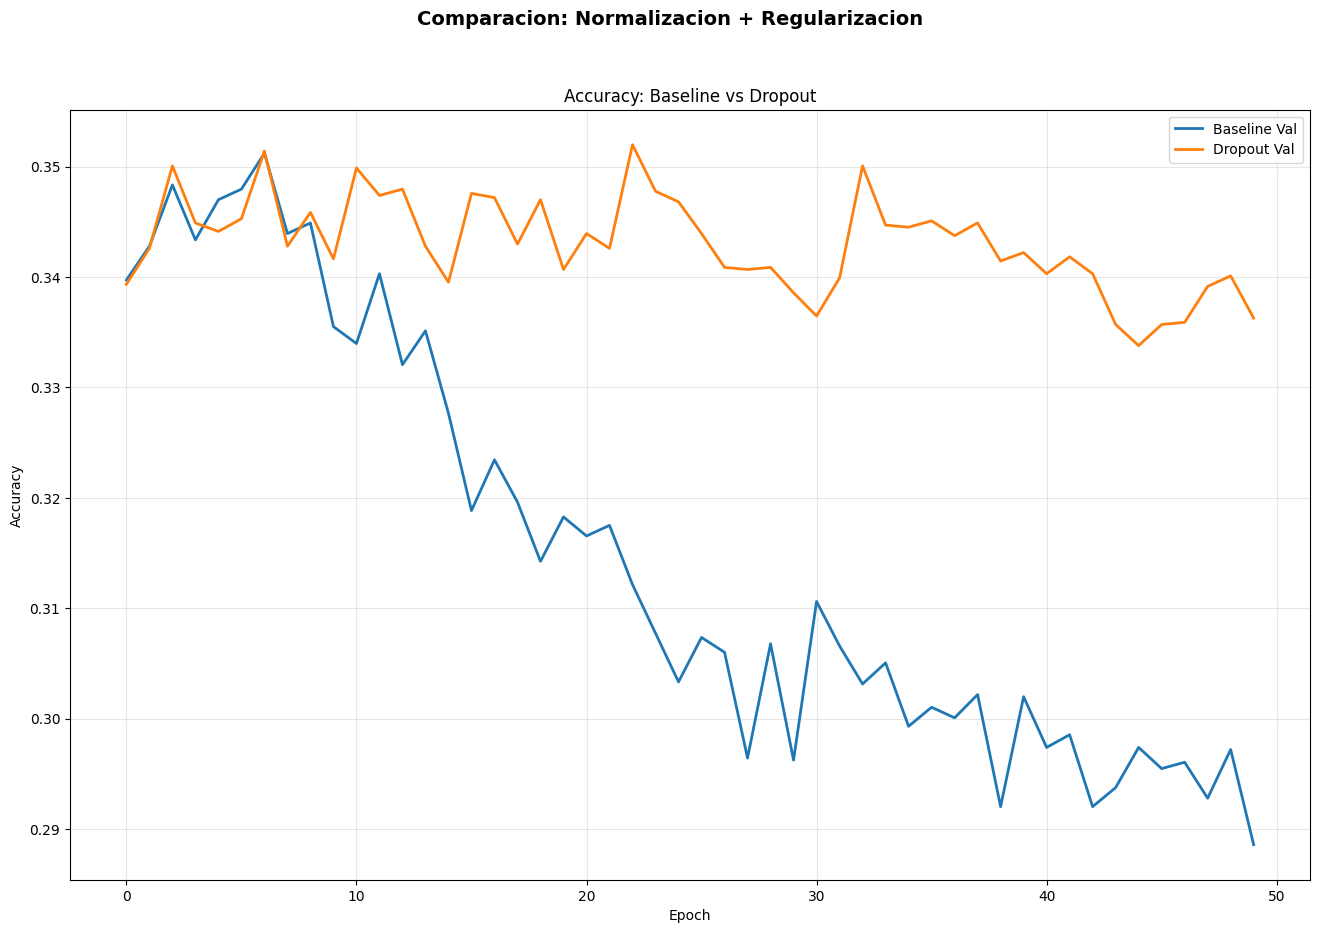

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
fig.suptitle('Comparacion: Normalizacion + Regularizacion', fontsize=14, fontweight='bold')

# Accuracy comparisons

ax.plot(histories['baseline']['val_acc'], label='Baseline Val', linewidth=2)
ax.plot(histories['dropout']['val_acc'], label='Dropout Val', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Baseline vs Dropout')
ax.legend()
ax.grid(True, alpha=0.3)
# Loss comparisons (Early Stopping)
plt.show()

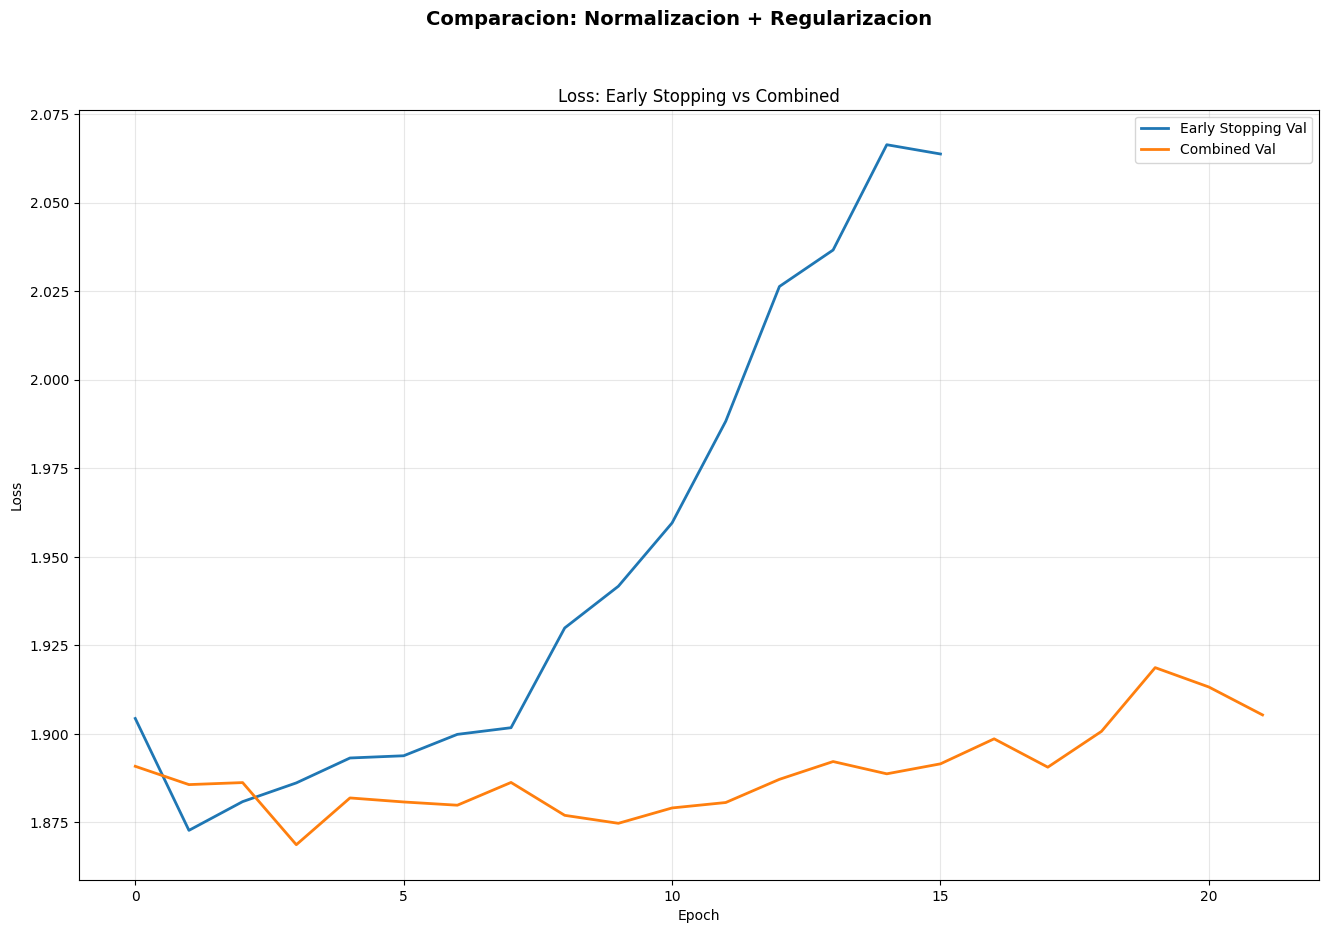

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
fig.suptitle('Comparacion: Normalizacion + Regularizacion', fontsize=14, fontweight='bold')

ax.plot(histories['early_stopping']['val_loss'], label='Early Stopping Val', linewidth=2)
ax.plot(histories['combined']['val_loss'], label='Combined Val', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss: Early Stopping vs Combined')
ax.legend()
ax.grid(True, alpha=0.3)

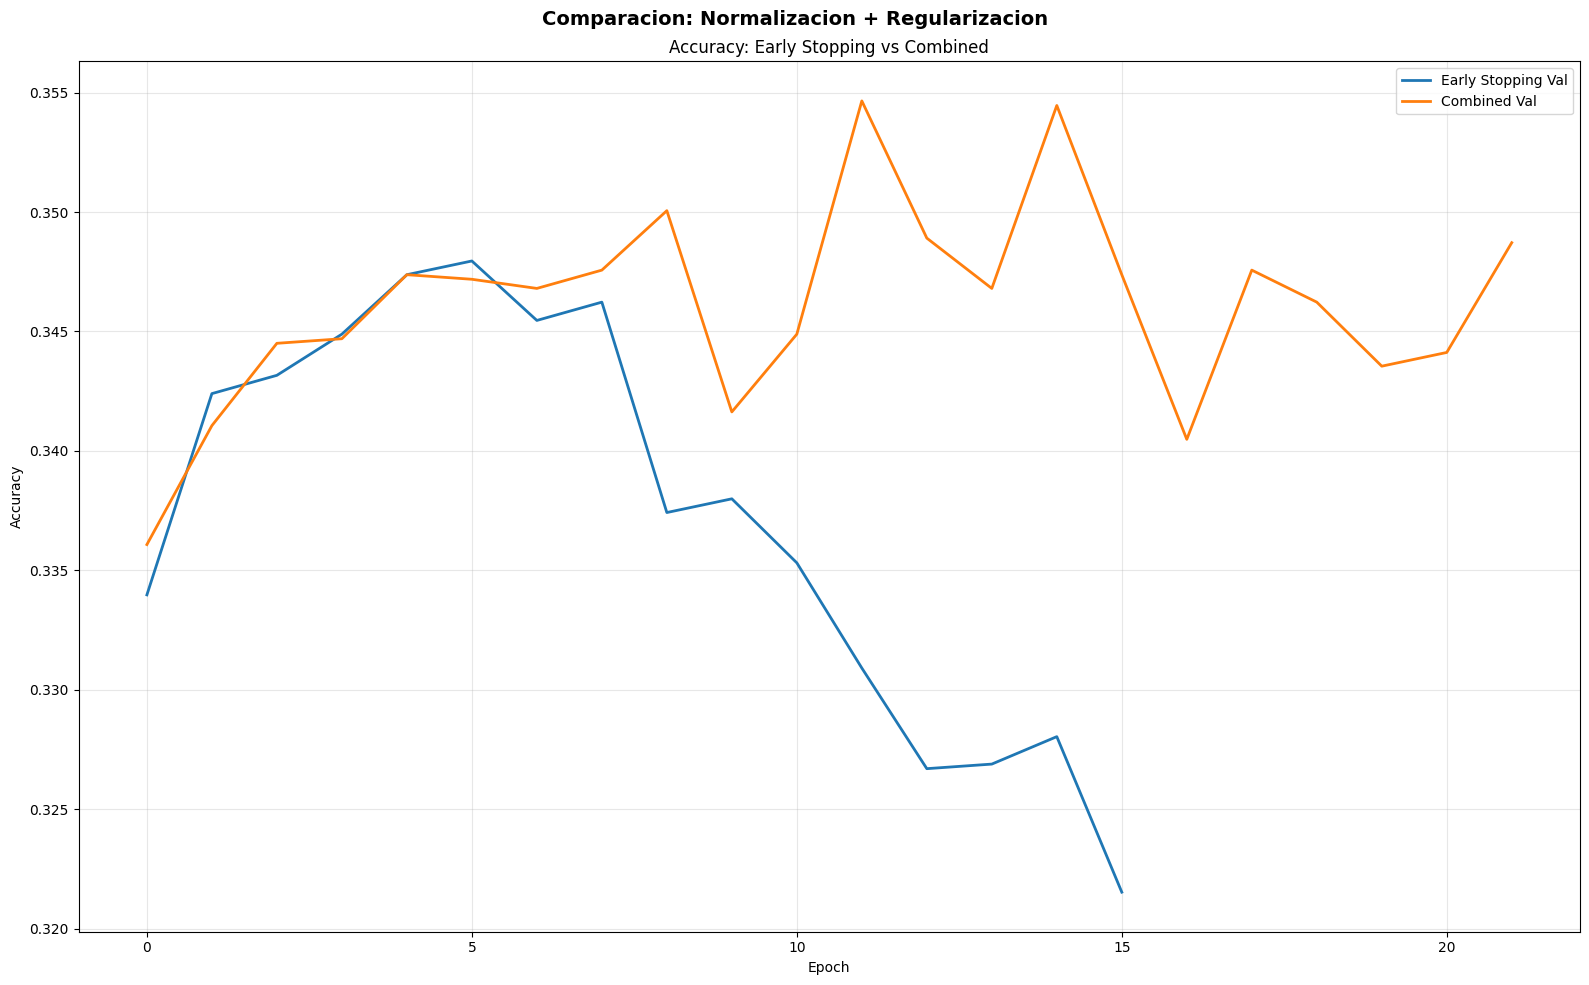

Graficos guardados como comparison.png


In [52]:
# Accuracy comparisons
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
fig.suptitle('Comparacion: Normalizacion + Regularizacion', fontsize=14, fontweight='bold')

ax.plot(histories['early_stopping']['val_acc'], label='Early Stopping Val', linewidth=2)
ax.plot(histories['combined']['val_acc'], label='Combined Val', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Early Stopping vs Combined')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()
print("Graficos guardados como comparison.png")

## 16. Evaluacion en Test Set

Obtener predicciones finales de todos los modelos en el conjunto de test.

In [33]:
def get_predictions(model, loader):
    """Obtiene predicciones y probabilidades."""
    model.eval()
    all_preds, all_proba, all_labels = [], [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_logits = model(X_batch)
            y_proba = torch.softmax(y_logits, dim=1)
            all_preds.extend(y_logits.argmax(dim=1).cpu().numpy())
            all_proba.extend(y_proba.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_proba)

print("Funcion get_predictions() definida")

Funcion get_predictions() definida


In [34]:
# Cargar mejores modelos y evaluar
predictions = {}

for name, model in models.items():
    model.load_state_dict(torch.load(f'{name}_best.pth'))
    y_true, y_pred, y_proba = get_predictions(model, test_loader)
    predictions[name] = {'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba}

print("Predicciones en test set obtenidas para todos los modelos")

Predicciones en test set obtenidas para todos los modelos


## 17. Calculo de Metricas

In [35]:
# Calcular todas las metricas
metrics_data = {
    'Modelo': [],
    'Val Acc': [],
    'Test Acc': [],
    'Precision': [],
    'Recall': [],
    'F1 (macro)': [],
    'Epocas': []
}

for name in ['baseline', 'dropout', 'early_stopping', 'combined']:
    y_true = predictions[name]['y_true']
    y_pred = predictions[name]['y_pred']
    y_proba = predictions[name]['y_proba']
    
    metrics_data['Modelo'].append(name.replace('_', ' ').title())
    metrics_data['Val Acc'].append(f"{max(histories[name]['val_acc']):.4f}")
    metrics_data['Test Acc'].append(f"{accuracy_score(y_true, y_pred):.4f}")
    metrics_data['Precision'].append(f"{precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    metrics_data['Recall'].append(f"{recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    metrics_data['F1 (macro)'].append(f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    metrics_data['Epocas'].append(len(histories[name]['train_loss']))

df_metrics = pd.DataFrame(metrics_data)

print("Metricas calculadas")

Metricas calculadas


## 18. Resumen Final y Conclusiones

In [36]:
print("\n" + "="*90)
print("RESUMEN FINAL - METRICAS DE TODOS LOS MODELOS")
print("="*90)
print(df_metrics.to_string(index=False))
print("="*90)


RESUMEN FINAL - METRICAS DE TODOS LOS MODELOS
        Modelo Val Acc Test Acc Precision Recall F1 (macro)  Epocas
      Baseline  0.3512   0.3626    0.2983 0.2528     0.2377      50
       Dropout  0.3520   0.3492    0.2605 0.2409     0.2295      50
Early Stopping  0.3480   0.3457    0.2717 0.2431     0.2344      16
      Combined  0.3547   0.3533    0.3337 0.2501     0.2341      22


In [37]:
print("\nCONCLUSIONES:")
print("-" * 90)
print("1. NORMALIZACION facilita convergencia y estabilidad del modelo")
print("   -> Sin normalizacion el modelo tarda mas en convergir")
print()
print("2. DROPOUT reduce overfitting y mejora generalizacion")
print("   -> El test accuracy mejora comparado al baseline")
print()
print("3. EARLY STOPPING ahorra tiempo evitando sobreentrenamiento")
print("   -> Se detiene cuando validacion deja de mejorar")
print()
print("4. COMBINACION de todas las tecnicas da el mejor rendimiento")
print("   -> Dropout + Early Stopping = mejor accuracy en test")
print("-" * 90)


CONCLUSIONES:
------------------------------------------------------------------------------------------
1. NORMALIZACION facilita convergencia y estabilidad del modelo
   -> Sin normalizacion el modelo tarda mas en convergir

2. DROPOUT reduce overfitting y mejora generalizacion
   -> El test accuracy mejora comparado al baseline

3. EARLY STOPPING ahorra tiempo evitando sobreentrenamiento
   -> Se detiene cuando validacion deja de mejorar

4. COMBINACION de todas las tecnicas da el mejor rendimiento
   -> Dropout + Early Stopping = mejor accuracy en test
------------------------------------------------------------------------------------------


## 19. Matriz de Confusion (Mejor Modelo)

In [38]:
# Matriz de confusion para el mejor modelo
y_true_best = predictions['combined']['y_true']
y_pred_best = predictions['combined']['y_pred']
cm = confusion_matrix(y_true_best, y_pred_best)

print(f"Matriz de confusion creada: {cm.shape}")
print(f"Dimension: {cm.shape[0]}x{cm.shape[1]} (una fila/columna por clase)")

Matriz de confusion creada: (14, 14)
Dimension: 14x14 (una fila/columna por clase)


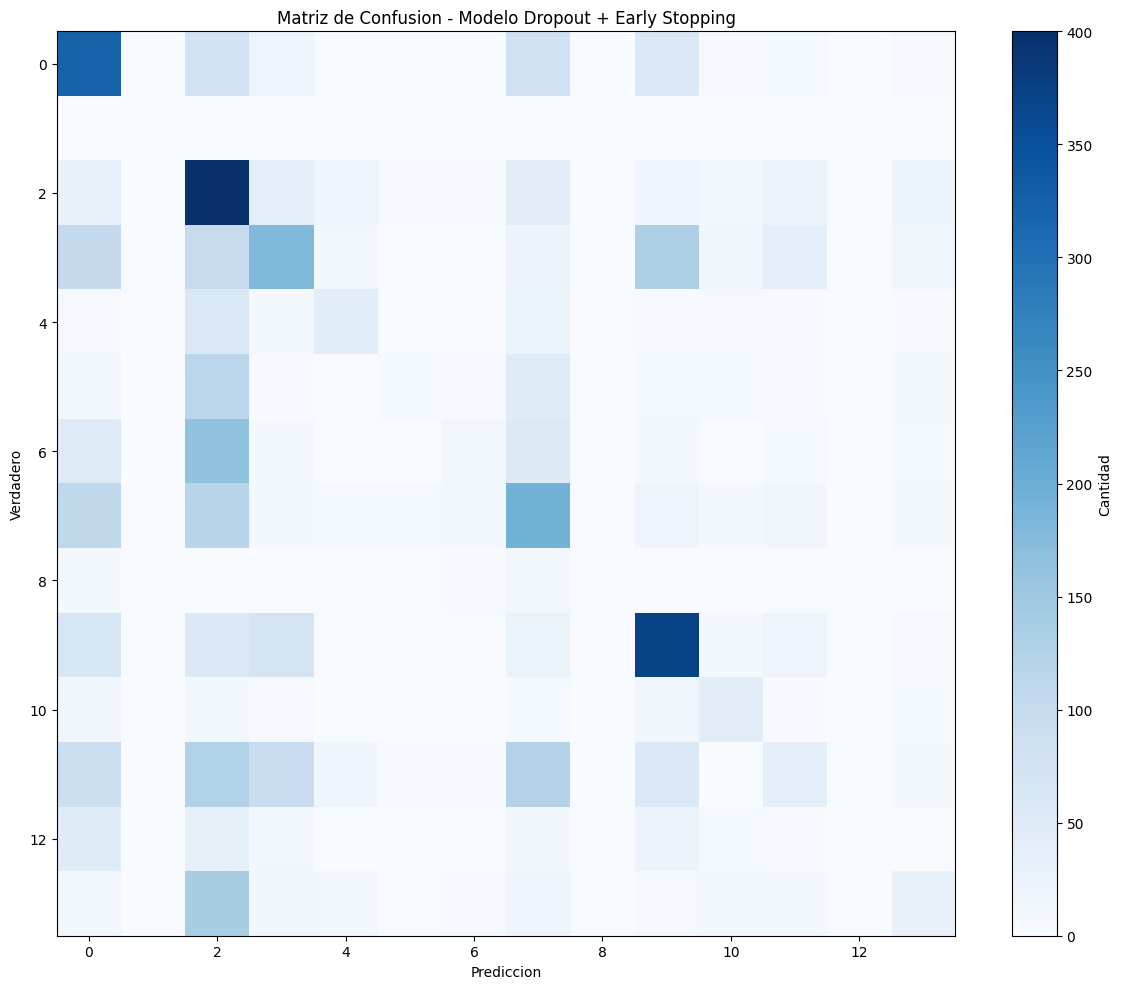

Matriz de confusion guardada como confusion_matrix.png


In [39]:
# Graficar matriz de confusion
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues', aspect='auto')
plt.xlabel('Prediccion')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusion - Modelo Dropout + Early Stopping')
plt.colorbar(label='Cantidad')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("Matriz de confusion guardada como confusion_matrix.png")